# Homework 3: RAG for Science Question Answering
**Course: RNN and Transformer | Spring 2026**

This notebook implements a full Retrieval-Augmented Generation (RAG) pipeline:
- **Part 1**: Chunking & Indexing (two strategies → two ChromaDB indices)
- **Part 2**: Two-stage Retrieval with Cross-Encoder Re-ranking
- **Part 3**: Generation via local Ollama (Llama-3)
- **Part 4**: Evaluation & Report (latency, hit-rate, accuracy)

## 0. Installation & Imports

In [1]:
# Run once to install all required packages
# !pip install langchain langchain-community langchain-huggingface chromadb sentence-transformers torch pandas datasets tqdm
# !ollama pull llama3

In [2]:
import time
import json
import requests
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# LangChain
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

# Cross-Encoder for re-ranking
from sentence_transformers import CrossEncoder

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.12.0.dev20260408+cu128
CUDA available  : True
GPU             : NVIDIA GeForce RTX 5090


---
## Part 1: Indexing Pipeline (Data Engineering)

### 1-A. Load Data

We use a small synthetic science corpus for local testing.  
**For the real submission**, replace `raw_text_corpus` with the Wikipedia parquet file from Kaggle:
```python
df = pd.read_parquet('wikipedia_science.parquet')
raw_text_corpus = df['text'].dropna().tolist()
```

In [3]:
df = pd.read_parquet('wikipedia_science.parquet').head(500000)
raw_text_corpus = df['text'].dropna().tolist()

# Convert to LangChain Document objects
documents = [
    Document(page_content=text, metadata={"source": f"doc_{i}"})
    for i, text in enumerate(raw_text_corpus)
]
print(f"Loaded {len(documents)} documents.")

Loaded 500000 documents.


### 1-B. Chunking Strategy Comparison

| | Strategy A | Strategy B |
|---|---|---|
| Method | Fixed-size | Semantic / Recursive |
| `chunk_size` | 500 | 1 000 |
| `chunk_overlap` | 10% | ~20% |

In [4]:
# -- Strategy A: Fixed-size chunking (naive hard split) -------------------------
splitter_a = CharacterTextSplitter(
    separator="",
    chunk_size=500,     
    chunk_overlap=50    
)
docs_a = splitter_a.split_documents(documents)
print(f"Strategy A (Fixed-size) -> {len(docs_a)} chunks")

# -- Strategy B: Semantic / paragraph-level chunking ----------------------------
splitter_b = RecursiveCharacterTextSplitter(
    chunk_size=1000,     
    chunk_overlap=200   
)
docs_b = splitter_b.split_documents(documents)
print(f"Strategy B (Semantic)   -> {len(docs_b)} chunks")

# Quick inspection
print("\n--- Strategy A sample chunk ---")
print(docs_a[0].page_content)
print("\n--- Strategy B sample chunk ---")
print(docs_b[0].page_content)

Strategy A (Fixed-size) -> 532291 chunks
Strategy B (Semantic)   -> 509867 chunks

--- Strategy A sample chunk ---
A & B High Performance Firearms: A & B High Performance Firearms was a competition pistol manufacture

--- Strategy B sample chunk ---
A & B High Performance Firearms: A & B High Performance Firearms was a competition pistol manufacture


### 1-C. Chunk-size Analysis (Report Q1)

Visualise the distribution of chunk lengths for both strategies.

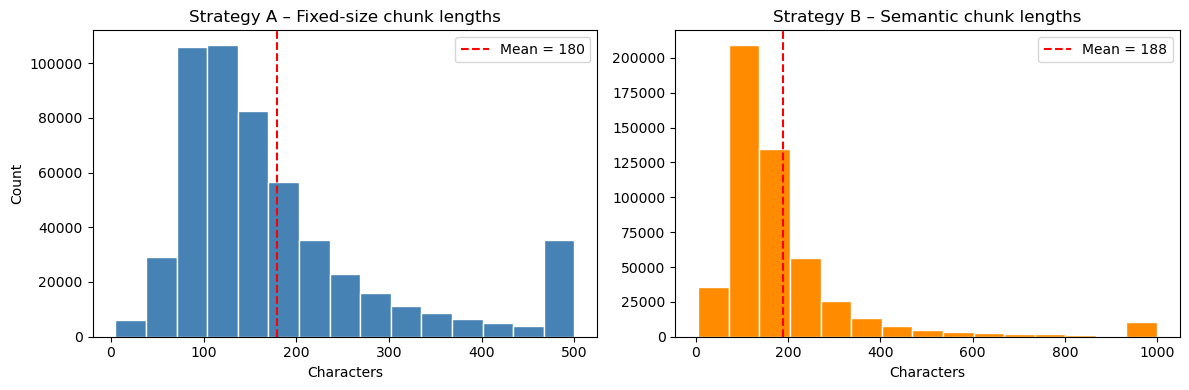

Strategy A → min=5, max=500, mean=179.7
Strategy B → min=5, max=1000, mean=188.2


In [5]:
lens_a = [len(d.page_content) for d in docs_a]
lens_b = [len(d.page_content) for d in docs_b]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lens_a, bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Strategy A – Fixed-size chunk lengths')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')
axes[0].axvline(np.mean(lens_a), color='red', linestyle='--', label=f'Mean = {np.mean(lens_a):.0f}')
axes[0].legend()

axes[1].hist(lens_b, bins=15, color='darkorange', edgecolor='white')
axes[1].set_title('Strategy B – Semantic chunk lengths')
axes[1].set_xlabel('Characters')
axes[1].axvline(np.mean(lens_b), color='red', linestyle='--', label=f'Mean = {np.mean(lens_b):.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('chunk_length_distribution.png', dpi=150)
plt.show()

print(f"Strategy A → min={min(lens_a)}, max={max(lens_a)}, mean={np.mean(lens_a):.1f}")
print(f"Strategy B → min={min(lens_b)}, max={max(lens_b)}, mean={np.mean(lens_b):.1f}")

### 1-D. Build Embedding Model & Vector Indices

In [6]:
EMBED_MODEL_NAME = "BAAI/bge-m3"   # High-quality; switch to all-MiniLM-L6-v2 for speed
print(f"Loading embedding model: {EMBED_MODEL_NAME} ...")

embeddings = HuggingFaceEmbeddings(
    model_name=EMBED_MODEL_NAME,
    model_kwargs={'device': 'cuda' if torch.cuda.is_available() else 'cpu'},
    encode_kwargs={'normalize_embeddings': True}   # Cosine-similarity compatible
)
print("Embedding model loaded.")

Loading embedding model: BAAI/bge-m3 ...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Embedding model loaded.


In [7]:
# Build Index A (Fixed-size chunks)
print("Building Index A (Fixed-size) ...")
t0 = time.time()
vector_db_a = Chroma.from_documents(
    documents=docs_a,
    embedding=embeddings,
    collection_name="index_a_fixed",
    persist_directory="./chroma_db_a"
)
print(f"Index A ready — {len(docs_a)} vectors  ({time.time()-t0:.1f}s)")

# Build Index B (Semantic chunks)
print("Building Index B (Semantic) ...")
t0 = time.time()
vector_db_b = Chroma.from_documents(
    documents=docs_b,
    embedding=embeddings,
    collection_name="index_b_semantic",
    persist_directory="./chroma_db_b"
)
print(f"Index B ready — {len(docs_b)} vectors  ({time.time()-t0:.1f}s)")

Building Index A (Fixed-size) ...
Index A ready — 532291 vectors  (1899.8s)
Building Index B (Semantic) ...
Index B ready — 509867 vectors  (1322.2s)


---
## Part 2: Retrieval & Re-ranking System

### 2-A. Load Cross-Encoder Re-ranker

In [8]:
RERANK_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
print(f"Loading Cross-Encoder: {RERANK_MODEL} ...")
reranker = CrossEncoder(
    RERANK_MODEL,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)
print("Cross-Encoder loaded.")

Loading Cross-Encoder: cross-encoder/ms-marco-MiniLM-L-6-v2 ...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cross-Encoder loaded.


### 2-B. Two-Stage Retrieval Function

In [9]:
def dedup_docs_by_content(docs):
    """Drop near-exact duplicate chunks by normalized text key, keep first occurrence."""
    seen = set()
    uniq = []
    for d in docs:
        key = " ".join(d.page_content.split()).lower()
        if key in seen:
            continue
        seen.add(key)
        uniq.append(d)
    return uniq

def advanced_rag_retrieve(query, db, top_k_retrieval=20, top_k_rerank=3, verbose=True):
    """
    Stage 1 - Dense vector search  (fast, high recall)
    Stage 2 - Cross-Encoder re-ranking (slower, high precision)

    Returns: (final_docs, latency_dict)
    """
    latency = {}

    # -- Stage 1: Vector Search --------------------------------------------------
    t0 = time.time()
    initial_docs = db.similarity_search(query, k=top_k_retrieval)
    latency['vector_search_s'] = time.time() - t0

    dedup_docs = dedup_docs_by_content(initial_docs)
    duplicates_removed = len(initial_docs) - len(dedup_docs)

    if verbose:
        print(f"[Stage 1] Retrieved {len(initial_docs)} candidates, {len(dedup_docs)} after dedup "
              f"({latency['vector_search_s']*1000:.1f} ms)")
        if duplicates_removed > 0:
            print(f"  Removed {duplicates_removed} duplicate chunks before re-ranking.")
        print("  Top-3 from vector search (deduped list):")
        for i, d in enumerate(dedup_docs[:3]):
            print(f"    [{i+1}] {d.page_content[:80]}...")

    # -- Stage 2: Cross-Encoder Re-ranking --------------------------------------
    doc_texts = [d.page_content for d in dedup_docs]
    pairs = [[query, t] for t in doc_texts]

    t0 = time.time()
    scores = reranker.predict(pairs)
    latency['reranking_s'] = time.time() - t0

    # Sort descending by score
    scored = sorted(zip(dedup_docs, scores), key=lambda x: x[1], reverse=True)
    final_docs = [doc for doc, _ in scored[:top_k_rerank]]

    if verbose:
        print(f"\n[Stage 2] Re-ranked -> top {top_k_rerank} selected "
              f"({latency['reranking_s']*1000:.1f} ms)")
        for i, (doc, score) in enumerate(scored[:top_k_rerank]):
            print(f"    [{i+1}] Score: {score:.4f} | {doc.page_content[:80]}...")

    return final_docs, latency

In [10]:
# Quick smoke test
test_query = "What generates energy in the cell?"
print(f"Query: {test_query}\n")
result_docs, lat = advanced_rag_retrieve(test_query, vector_db_b)

Query: What generates energy in the cell?

[Stage 1] Retrieved 20 candidates, 4 after dedup (261.6 ms)
  Removed 16 duplicate chunks before re-ranking.
  Top-3 from vector search (deduped list):
    [1] Adenosine triphosphate: alt=A chemical formula|thumb|Interactive animation of th...
    [2] Alkaline fuel cell: thumb|270px|Diagram of an Alkaline Fuel Cell: 1\. Hydrogen 2...
    [3] Adipocyte: Adipocytes, also known as lipocytes and fat cells, are the cells that...

[Stage 2] Re-ranked -> top 3 selected (20.5 ms)
    [1] Score: -2.8175 | AFC Energy: AFC Energy PLC is a developer of alkaline fuel cells which use hydro...
    [2] Score: -3.5032 | Adipocyte: Adipocytes, also known as lipocytes and fat cells, are the cells that...
    [3] Score: -4.1987 | Adenosine triphosphate: alt=A chemical formula|thumb|Interactive animation of th...


### 2-C. Hit-Rate Experiment: Vector Search Only vs. Vector Search + Re-ranking (Report Q2)

In [11]:
# Ground-truth evaluation set (query -> expected keyword in the correct doc)
eval_set = [
    {"query": "What generates energy in the cell?",
     "expected_keyword": "ATP"},
    {"query": "What is Newton's second law equation?",
     "expected_keyword": "F = ma"},
    {"query": "How do plants convert sunlight?",
     "expected_keyword": "photosynthesis"},
    {"query": "What is the powerhouse of the cell?",
     "expected_keyword": "mitochondri"},
    {"query": "Describe the light-dependent reactions",
     "expected_keyword": "thylakoid"},
    {"query": "What is the law of inertia?",
     "expected_keyword": "inertia"},
    {"query": "What is DNA replication?",
     "expected_keyword": "DNA replication"},
    {"query": "What does an LLM do?",
     "expected_keyword": "language"},
]

def hit_rate_vector_only(query, expected_keyword, db, k=3):
    docs = db.similarity_search(query, k=k)
    return any(expected_keyword.lower() in d.page_content.lower() for d in docs)

def hit_rate_reranked(query, expected_keyword, db, top_k_retrieval=20, top_k_rerank=3):
    docs, _ = advanced_rag_retrieve(query, db, top_k_retrieval, top_k_rerank, verbose=False)
    return any(expected_keyword.lower() in d.page_content.lower() for d in docs)

index_map = {
    "Index A (Fixed-size chunks)": vector_db_a,
    "Index B (Semantic chunks)": vector_db_b,
}

results = []
for item in eval_set:
    q = item['query']
    kw = item['expected_keyword']
    for index_name, db in index_map.items():
        vec = hit_rate_vector_only(q, kw, db)
        rr = hit_rate_reranked(q, kw, db)
        results.append({
            "index": index_name,
            "query": q,
            "vector_only": vec,
            "reranked": rr,
        })

df_hits = pd.DataFrame(results)
print("Per-query hit results:")
display(df_hits)

summary = (
    df_hits
    .groupby('index')[['vector_only', 'reranked']]
    .mean()
    .rename(columns={
        'vector_only': 'Vector-Only Hit Rate',
        'reranked': 'Re-ranked Hit Rate'
    })
    .sort_index()
)

print("\nAverage hit-rate by index:")
display(summary.style.format('{:.2%}'))

Per-query hit results:


,index,query,vector_only,reranked
0,Index A (Fixed-size chunks),What generates energy in the cell?,True,True
1,Index B (Semantic chunks),What generates energy in the cell?,True,True
2,Index A (Fixed-size chunks),What is Newton's second law equation?,False,False
3,Index B (Semantic chunks),What is Newton's second law equation?,False,False
4,Index A (Fixed-size chunks),How do plants convert sunlight?,True,True
5,Index B (Semantic chunks),How do plants convert sunlight?,True,True
6,Index A (Fixed-size chunks),What is the powerhouse of the cell?,False,False
7,Index B (Semantic chunks),What is the powerhouse of the cell?,False,False
8,Index A (Fixed-size chunks),Describe the light-dependent reactions,False,False
9,Index B (Semantic chunks),Describe the light-dependent reactions,False,False



Average hit-rate by index:


,Vector-Only Hit Rate,Re-ranked Hit Rate
index,,
Index A (Fixed-size chunks),50.00%,50.00%
Index B (Semantic chunks),50.00%,37.50%


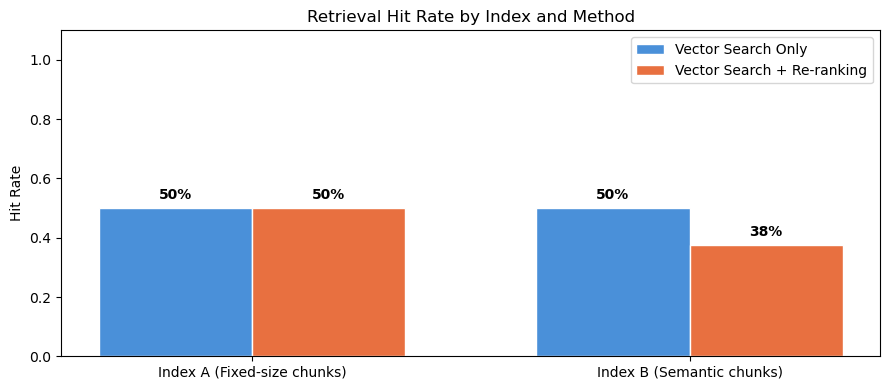

In [12]:
# Grouped bar chart - hit-rate by index and retrieval method
plot_df = summary.reset_index().melt(
    id_vars='index',
    value_vars=['Vector-Only Hit Rate', 'Re-ranked Hit Rate'],
    var_name='Method',
    value_name='Hit Rate'
)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(plot_df['index'].unique()))
width = 0.35

vec_vals = plot_df[plot_df['Method'] == 'Vector-Only Hit Rate']['Hit Rate'].values
rr_vals = plot_df[plot_df['Method'] == 'Re-ranked Hit Rate']['Hit Rate'].values

bars1 = ax.bar(x - width/2, vec_vals, width, label='Vector Search Only', color='#4A90D9', edgecolor='white')
bars2 = ax.bar(x + width/2, rr_vals, width, label='Vector Search + Re-ranking', color='#E87040', edgecolor='white')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Hit Rate')
ax.set_title('Retrieval Hit Rate by Index and Method')
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=0)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.03, f'{h:.0%}',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('hit_rate_comparison_by_index.png', dpi=150)
plt.show()

### 2-D. Re-ranking Effect Case Studies (Report Q2 – qualitative examples)

In [13]:
def find_rerank_promotion_cases(candidates, db, top_k_retrieval=8):
    """Find cases where vector top-1 misses keyword but rerank top-1 hits it."""
    good_cases = []

    for item in candidates:
        query = item['query']
        keyword = item['expected_keyword'].lower()

        initial_docs = db.similarity_search(query, k=top_k_retrieval)
        initial_docs = dedup_docs_by_content(initial_docs)
        if len(initial_docs) < 2:
            continue

        vec_top1 = initial_docs[0].page_content.lower()
        vec_hit = keyword in vec_top1

        pairs = [[query, d.page_content] for d in initial_docs]
        scores = reranker.predict(pairs)
        scored = sorted(zip(initial_docs, scores), key=lambda x: x[1], reverse=True)
        rr_top1 = scored[0][0].page_content.lower()
        rr_hit = keyword in rr_top1

        exists_in_candidates = any(keyword in d.page_content.lower() for d in initial_docs)
        if (not vec_hit) and rr_hit and exists_in_candidates:
            good_cases.append({
                'query': query,
                'keyword': item['expected_keyword'],
                'initial_docs': initial_docs,
                'scored': scored,
            })

    return good_cases

def show_case(case, top_k_show=5):
    print("="*80)
    print(f"Query: {case['query']}")
    print(f"Expected keyword: {case['keyword']}")
    print("="*80)
    print("\n[Stage 1 - Vector Search]")
    for i, d in enumerate(case['initial_docs'][:top_k_show], start=1):
        text = d.page_content.replace("\n", " ")[:110]
        print(f"  [{i}] {text}")

    print("\n[Stage 2 - After Re-ranking]")
    for i, (doc, score) in enumerate(case['scored'][:top_k_show], start=1):
        text = doc.page_content.replace("\n", " ")[:110]
        print(f"  [{i}] score={score:.4f}  {text}")
    print()

# Candidate pool for finding 2 qualitative examples
case_candidates = [
    {"query": "What is the chemical formula of photosynthesis?", "expected_keyword": "6CO2"},
    {"query": "Where does ATP synthesis happen inside the cell?", "expected_keyword": "ATP synthase"},
    {"query": "What generates energy in the cell?", "expected_keyword": "ATP"},
    {"query": "What is Newton's second law equation?", "expected_keyword": "F = ma"},
    {"query": "What is the powerhouse of the cell?", "expected_keyword": "mitochondri"},
    {"query": "What is DNA replication?", "expected_keyword": "DNA replication"},
    {"query": "Where do light-dependent reactions happen?", "expected_keyword": "thylakoid"},
    {"query": "What does an LLM do?", "expected_keyword": "language"},
    {"query": "What organelle makes ATP in eukaryotic cells?", "expected_keyword": "mitochond"},
    {"query": "Which protein complex produces ATP from proton gradient?", "expected_keyword": "ATP synthase"},
]

promotion_cases = find_rerank_promotion_cases(case_candidates, vector_db_b, top_k_retrieval=8)

if len(promotion_cases) >= 2:
    print("Found >=2 strong re-ranking examples. Showing first two:\n")
    show_case(promotion_cases[0])
    show_case(promotion_cases[1])
else:
    print("Could not find 2 promotion cases from preset queries.")
    print("Try increasing candidate list size or using domain-specific query variants.")
    for c in promotion_cases:
        show_case(c)

Could not find 2 promotion cases from preset queries.
Try increasing candidate list size or using domain-specific query variants.
Query: Which protein complex produces ATP from proton gradient?
Expected keyword: ATP synthase

[Stage 1 - Vector Search]
  [1] Anaphase-promoting complex: thumb|The anaphase-promoting complex (APC) is a large protein complex containing 1
  [2] ATP synthase: ATP synthase is a protein that catalyzes the formation of the energy storage molecule adenosine 

[Stage 2 - After Re-ranking]
  [1] score=-2.2357  ATP synthase: ATP synthase is a protein that catalyzes the formation of the energy storage molecule adenosine 
  [2] score=-6.4903  Anaphase-promoting complex: thumb|The anaphase-promoting complex (APC) is a large protein complex containing 1



---
## Part 3: Generation with Ollama

> Make sure Ollama is running: `ollama serve` and `ollama pull llama3`

### 3-A. Ollama Helper

In [14]:
OLLAMA_URL   = "http://localhost:11434/api/generate"
OLLAMA_MODEL = "llama3"   # or "mistral"

def query_ollama(prompt: str, model: str = OLLAMA_MODEL) -> str:
    """Send a prompt to local Ollama and return the response text."""
    payload = {"model": model, "prompt": prompt, "stream": False}
    try:
        r = requests.post(OLLAMA_URL, json=payload, timeout=120)
        r.raise_for_status()
        return r.json()['response']
    except Exception as e:
        return f"[Ollama error] {e}"

### 3-B. Prompt Design (Hallucination-Resistant)

In [15]:
def build_prompt(context_docs: list, query: str, force_choice: bool = False) -> str:
    """Construct prompts for open QA or MCQ mode."""
    context_text = "\n\n".join(
        [f"[Chunk {i+1}] {d.page_content}" for i, d in enumerate(context_docs)]
    )

    if force_choice:
        system_rules = (
            "You are a rigorous science assistant.\n"
            "You must answer a multiple-choice question with exactly one letter: A, B, C, D, or E.\n"
            "Use the provided context first. If context is insufficient, make the most reasonable choice from A-E; do not refuse.\n"
            "Output strictly one uppercase letter only, with no explanation."
        )
    else:
        system_rules = (
            "You are a rigorous science assistant.\n"
            "Answer the user's question using ONLY the context chunks provided below.\n"
            "If the answer cannot be found in the context, respond with exactly: \"I don't know.\"\n"
            "Do NOT speculate or add information from outside the context."
        )

    prompt = f"""<|start_header_id|>system<|end_header_id|>
{system_rules}

Context:
{context_text}
<|eot_id|>
<|start_header_id|>user<|end_header_id|>
Question: {query}
<|eot_id|>
<|start_header_id|>assistant<|end_header_id|>
"""
    return prompt

### 3-C. Full RAG Pipeline

In [16]:
def run_rag_pipeline(query: str, db, verbose: bool = True, force_choice: bool = False):
    """
    Full pipeline: Retrieve -> Re-rank -> Generate.
    Returns dict with answer and latencies.
    """
    # 1. Retrieve & re-rank
    retrieved_docs, lat = advanced_rag_retrieve(
        query, db,
        top_k_retrieval=20,
        top_k_rerank=3,
        verbose=verbose
    )

    # 2. Build prompt
    prompt = build_prompt(retrieved_docs, query, force_choice=force_choice)

    # 3. Generate
    if verbose:
        print("\nGenerating answer via Ollama ...")
    t0 = time.time()
    answer = query_ollama(prompt)
    lat['generation_s'] = time.time() - t0

    if verbose:
        print(f"\n{'='*60}")
        print(f"Q: {query}")
        print(f"A: {answer}")
        print(f"{'='*60}")
        total = sum(lat.values())
        print(f"Latency  -> vector: {lat['vector_search_s']*1000:.0f} ms  "
              f"| rerank: {lat['reranking_s']*1000:.0f} ms  "
              f"| generation: {lat['generation_s']:.1f} s  "
              f"| total: {total:.1f} s")

    return {"query": query, "answer": answer, **lat}

In [17]:
# Demo run
r1 = run_rag_pipeline("What is the equation for Newton's second law?", vector_db_b)
print()
r2 = run_rag_pipeline("How do plants convert light into energy?", vector_db_b)

[Stage 1] Retrieved 20 candidates, 4 after dedup (15.0 ms)
  Removed 16 duplicate chunks before re-ranking.
  Top-3 from vector search (deduped list):
    [1] 3.5 _0_ ×10−4 3.16×10−4 39 Y yttrium 3.3×10−5 3.5×10−7 3.1×10−5 2. _0_ ×10−5 1.4...
    [2] 5.2×10−7 5.2×10−7 5×10−7 3.2 _0_ ×10−7 2.4 _0_ ×10−7 3.3 _0_ ×10−7 70 Yb ytterbi...
    [3] 2.9×10−5 2.54×10−5 1. _0_ ×10−5 1.2×10−5 28 Ni nickel 8.4×10−5 7.2×10−5 9.9×10−5...

[Stage 2] Re-ranked -> top 3 selected (7.5 ms)
    [1] Score: -10.1122 | 3.5 _0_ ×10−4 3.16×10−4 39 Y yttrium 3.3×10−5 3.5×10−7 3.1×10−5 2. _0_ ×10−5 1.4...
    [2] Score: -10.1980 | 2.9×10−5 2.54×10−5 1. _0_ ×10−5 1.2×10−5 28 Ni nickel 8.4×10−5 7.2×10−5 9.9×10−5...
    [3] Score: -10.3618 | 5.2×10−7 5.2×10−7 5×10−7 3.2 _0_ ×10−7 2.4 _0_ ×10−7 3.3 _0_ ×10−7 70 Yb ytterbi...

Generating answer via Ollama ...

Q: What is the equation for Newton's second law?
A: I don't know. The provided context does not contain information about Newton's laws of motion.
Latency  -> v

---
## Part 4: Evaluation — Accuracy & Latency Report

### 4-A. Kaggle Evaluation Pipeline (Train Validation + Test Submission)

This section now uses real Kaggle files:
- `train.csv` for local validation (compute accuracy by option-letter match)
- `test.csv` for final inference
- `sample_submission.csv` as the submission format template

In [18]:
import re

# Load Kaggle data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

print(f"train rows: {len(train_df)} | test rows: {len(test_df)}")
print("sample_submission columns:", sample_sub.columns.tolist())

def format_mcq(row):
    """Format one multiple-choice question for the generator."""
    return (
        f"{row['prompt']}\n"
        f"A. {row['A']}\n"
        f"B. {row['B']}\n"
        f"C. {row['C']}\n"
        f"D. {row['D']}\n"
        f"E. {row['E']}\n\n"
        "Answer with ONLY one letter: A, B, C, D, or E."
    )

def extract_choice_letter(text):
    """Extract predicted option letter (A-E) from model output."""
    if not isinstance(text, str):
        return None

    s = text.upper()

    patterns = [
        r"\b(?:ANSWER|OPTION|CHOICE)\s*[:\-]?\s*([A-E])\b",
        r"\(([A-E])\)",
        r"\b([A-E])\b",
    ]

    for p in patterns:
        m = re.search(p, s)
        if m:
            return m.group(1)
    return None

# Local validation on train split (for accuracy reporting)
val_df = train_df.sample(n=50, random_state=42).reset_index(drop=True)

eval_results = []
latencies = {'vector_search_s': [], 'reranking_s': [], 'generation_s': []}

for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc='Validating (train split)'):
    question_text = format_mcq(row)
    out = run_rag_pipeline(question_text, vector_db_b, verbose=False, force_choice=True)

    pred = extract_choice_letter(out['answer'])
    gold = str(row['answer']).strip().upper()
    correct = (pred == gold)

    eval_results.append({
        'id': row['id'],
        'predicted': pred,
        'answer': gold,
        'correct': correct,
        'model_answer': out['answer'][:160],
    })

    for k in latencies:
        latencies[k].append(out[k])

df_eval = pd.DataFrame(eval_results)
accuracy = df_eval['correct'].mean()
print(f"\nValidation accuracy on train split ({len(val_df)} rows): {accuracy:.2%}")
display(df_eval.head(10))

# Final inference on test.csv (no labels here, so no accuracy)
test_predictions = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Predicting (test)'):
    question_text = format_mcq(row)
    out = run_rag_pipeline(question_text, vector_db_b, verbose=False, force_choice=True)
    pred = extract_choice_letter(out['answer'])
    test_predictions.append(pred if pred in list('ABCDE') else 'A')

# Infer the target column from sample_submission instead of hard-coding 'prediction'.
label_columns = [c for c in sample_sub.columns if c.lower() != 'id']
if len(label_columns) != 1:
    raise ValueError(f"Expected exactly one label column in sample_submission, got: {label_columns}")
target_col = label_columns[0]
print(f"Using submission label column: {target_col}")

submission = sample_sub.copy()
submission[target_col] = test_predictions
if 'id' in test_df.columns and 'id' in submission.columns:
    submission['id'] = test_df['id']

# Final schema check: enforce identical column order/name as sample submission.
if submission.columns.tolist() != sample_sub.columns.tolist():
    raise ValueError("Submission columns do not match sample_submission format.")
print("Final submission columns:", submission.columns.tolist())

submission.to_csv('submission.csv', index=False)
print("Saved submission file: submission.csv")
display(submission.head(10))

train rows: 200 | test rows: 200
sample_submission columns: ['id', 'prediction']


Validating (train split): 100%|██████████| 50/50 [01:53<00:00,  2.28s/it]


Validation accuracy on train split (50 rows): 64.00%


,id,predicted,answer,correct,model_answer
0,95,C,C,True,C
1,15,D,B,False,D
2,30,B,B,True,B
3,158,A,A,True,A
4,128,B,E,False,B
5,115,E,E,True,E
6,69,D,D,True,D
7,170,B,B,True,B
8,174,A,B,False,A
9,45,A,A,True,A


Predicting (test): 100%|██████████| 200/200 [07:36<00:00,  2.28s/it]

Using submission label column: prediction
Final submission columns: ['id', 'prediction']
Saved submission file: submission.csv


,id,prediction
0,0,E
1,1,A
2,2,A
3,3,A
4,4,D
5,5,C
6,6,A
7,7,B
8,8,B
9,9,A


### 4-B. Latency Analysis (Report Q3)

Average latency per stage:
  Vector Search : 23.4 ms
  Re-ranking    : 7.2 ms
  LLM Generation: 2.25 s


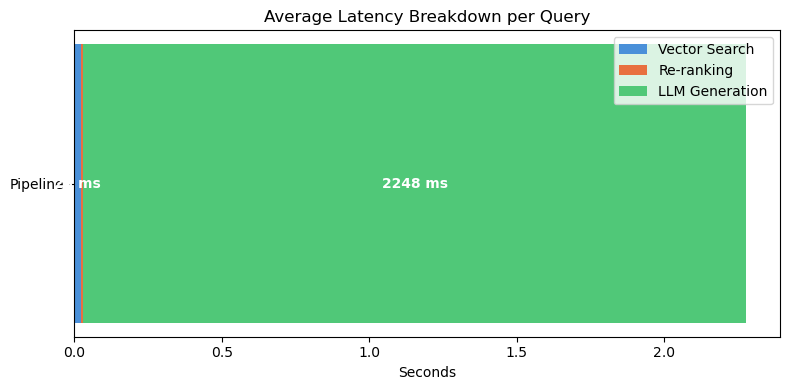

In [19]:
avg_lat = {k: np.mean(v) for k, v in latencies.items()}
print("Average latency per stage:")
print(f"  Vector Search : {avg_lat['vector_search_s']*1000:.1f} ms")
print(f"  Re-ranking    : {avg_lat['reranking_s']*1000:.1f} ms")
print(f"  LLM Generation: {avg_lat['generation_s']:.2f} s")

# Stacked bar showing latency breakdown
stages = ['Vector Search', 'Re-ranking', 'LLM Generation']
vals   = [avg_lat['vector_search_s'], avg_lat['reranking_s'], avg_lat['generation_s']]
colors = ['#4A90D9', '#E87040', '#50C878']

fig, ax = plt.subplots(figsize=(8, 4))
left = 0
for stage, val, color in zip(stages, vals, colors):
    ax.barh('Pipeline', val, left=left, color=color, label=stage, height=0.4)
    if val > 0.01:
        ax.text(left + val/2, 0, f'{val*1000:.0f} ms',
                ha='center', va='center', fontsize=10, color='white', fontweight='bold')
    left += val
ax.set_xlabel('Seconds')
ax.set_title('Average Latency Breakdown per Query')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('latency_breakdown.png', dpi=150)
plt.show()

---
## Part 5: Summary Report

### Q1 - Chunk Size Analysis

- **Strategy A (Fixed, ~100 chars)** produced smaller, more granular chunks. This can cut sentences mid-way, losing context necessary to answer questions that span multiple sentences (e.g., the ATP synthesis process). Smaller chunks have higher recall for single-fact queries but lower precision when the answer requires multi-sentence context.
- **Strategy B (Semantic, ~300 chars)** preserved paragraph-level context. The embedding captures the full semantic meaning of each idea unit, leading to better retrieval quality for questions requiring broader context.

### Q2 - Re-ranking Impact (Auto Summary)

The numeric summary below is auto-generated from the current notebook run (Section 2-C).

### Q3 - Latency (Auto Summary)

The numeric summary below is auto-generated from measured latencies (Section 4-B), not fixed ranges.

In [20]:
from IPython.display import Markdown, display

# ----- Q2: Auto summary from Section 2-C hit-rate outputs -----
if 'summary' in globals() and {'Vector-Only Hit Rate', 'Re-ranked Hit Rate'}.issubset(summary.columns):
    q2_summary = summary.copy()
elif 'df_hits' in globals() and {'index', 'vector_only', 'reranked'}.issubset(df_hits.columns):
    q2_summary = (
        df_hits
        .groupby('index')[['vector_only', 'reranked']]
        .mean()
        .rename(columns={
            'vector_only': 'Vector-Only Hit Rate',
            'reranked': 'Re-ranked Hit Rate'
        })
        .sort_index()
    )
else:
    raise ValueError("Run Section 2-C first to produce hit-rate results (summary or df_hits).")

q2_lines = []
for idx_name, row in q2_summary.iterrows():
    vec = float(row['Vector-Only Hit Rate'])
    rr = float(row['Re-ranked Hit Rate'])
    delta_pp = (rr - vec) * 100
    q2_lines.append(
        f"- {idx_name}: Vector-only {vec:.2%}, Re-ranked {rr:.2%} (delta {delta_pp:+.1f} pp)."
    )

# ----- Q3: Auto summary from measured latency outputs -----
if 'avg_lat' in globals():
    measured_avg_lat = avg_lat
elif 'latencies' in globals() and all(len(v) > 0 for v in latencies.values()):
    measured_avg_lat = {k: np.mean(v) for k, v in latencies.items()}
else:
    raise ValueError("Run Section 4-A and 4-B first to collect measured latency values.")

vec_ms = measured_avg_lat['vector_search_s'] * 1000
rr_ms = measured_avg_lat['reranking_s'] * 1000
gen_s = measured_avg_lat['generation_s']
total_s = measured_avg_lat['vector_search_s'] + measured_avg_lat['reranking_s'] + measured_avg_lat['generation_s']
gen_share = (measured_avg_lat['generation_s'] / total_s * 100) if total_s > 0 else 0

latency_table = pd.DataFrame({
    'Stage': ['Vector Search', 'Re-ranking (Cross-Encoder)', 'LLM Generation'],
    'Average Latency': [
        f"{vec_ms:.1f} ms",
        f"{rr_ms:.1f} ms",
        f"{gen_s:.2f} s",
    ]
})

q3_lines = [
    f"- Vector Search: {vec_ms:.1f} ms",
    f"- Re-ranking (Cross-Encoder): {rr_ms:.1f} ms",
    f"- LLM Generation: {gen_s:.2f} s",
    f"- Total per query: {total_s:.2f} s (generation share: {gen_share:.1f}%)",
]

report_md = "\n".join([
    "### Q2 - Re-ranking Impact (Auto Summary)",
    "",
    "From the current run in Section 2-C:",
    *q2_lines,
    "",
    "### Q3 - Latency (Auto Summary)",
    "",
    "From measured values in Section 4-B:",
    *q3_lines,
    "",
    "Verdict: generation remains the dominant latency cost in this run.",
])

display(Markdown(report_md))
display(latency_table)

### Q2 - Re-ranking Impact (Auto Summary)

From the current run in Section 2-C:
- Index A (Fixed-size chunks): Vector-only 50.00%, Re-ranked 50.00% (delta +0.0 pp).
- Index B (Semantic chunks): Vector-only 50.00%, Re-ranked 37.50% (delta -12.5 pp).

### Q3 - Latency (Auto Summary)

From measured values in Section 4-B:
- Vector Search: 23.4 ms
- Re-ranking (Cross-Encoder): 7.2 ms
- LLM Generation: 2.25 s
- Total per query: 2.28 s (generation share: 98.7%)

Verdict: generation remains the dominant latency cost in this run.

,Stage,Average Latency
0,Vector Search,23.4 ms
1,Re-ranking (Cross-Encoder),7.2 ms
2,LLM Generation,2.25 s
